# 04 — Threshold strategy: from prediction to P&L

At each month-end I take the OOS predictions for that day, go long every symbol whose predicted 21d return exceeds a threshold τ (equal-weighted), hold 21 trading days, then rebalance. Benchmarks are the S&P 500 and an equal-weight all-symbols portfolio. Costs are 5 bps one-way via `qtools.backtest.costs.US_EQUITY`, charged on turnover each rebalance.

I sweep τ ∈ {0, 0.5σ, 1σ} where σ is the training-period cross-sectional std of predictions. The main question: does tightening the threshold actually improve the basket, or do the absolute-return magnitudes not rank reliably enough to justify it?

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from qtools.backtest.costs import US_EQUITY

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

ROOT = Path("..").resolve()
PREDS = ROOT / "reports" / "predictions" / "oos_2020_2024.parquet"
MACRO = sorted((ROOT / "data" / "raw").glob("macro_*.parquet"))[-1]

preds = pd.read_parquet(PREDS)
preds["date"] = pd.to_datetime(preds["date"])
pred_cols = [c for c in preds.columns if c.startswith("pred_")]
print(f"{len(preds):,} rows · models:", [c.removeprefix('pred_') for c in pred_cols])

COST_BPS = US_EQUITY.commission_bps + US_EQUITY.slippage_bps
print(f"One-way cost: {COST_BPS:.1f} bps")

631,516 rows · models: ['linear_ridge', 'linear_lasso', 'lgbm_regressor', 'xgb_regressor', 'hist_mean']
One-way cost: 5.0 bps


## 1. Monthly rebalance loop

In [2]:
# Month-end selection dates: the last trading day in each month that has
# predictions. We'll use each month's final prediction date as the
# decision point, then apply the realised 21d forward return (y_true)
# until the next rebalance.
preds["ym"] = preds["date"].values.astype("datetime64[M]")
rebal_dates = preds.groupby("ym")["date"].max().sort_values()
print(f"Rebalance points: {len(rebal_dates)} (monthly 2020-2024)")
rebal_dates.head()

Rebalance points: 60 (monthly 2020-2024)


ym
2020-01-01   2020-01-31
2020-02-01   2020-02-28
2020-03-01   2020-03-31
2020-04-01   2020-04-30
2020-05-01   2020-05-29
Name: date, dtype: datetime64[ms]

In [3]:
def backtest_threshold(model_col: str, tau_sigmas: float) -> pd.DataFrame:
    '''Long equal-weight everyone with pred > mu + tau*sigma (per month).

    tau_sigmas=0 means "long everything with positive predicted return".
    Returns a DataFrame indexed by rebalance date with: n_long, ret_gross,
    turnover, ret_net.
    '''
    rows = []
    prev_basket = set()
    for d in rebal_dates:
        day = preds[preds["date"] == d].dropna(subset=[model_col, "y_true"])
        if day.empty:
            continue
        mu, sigma = day[model_col].mean(), day[model_col].std()
        thresh = mu + tau_sigmas * sigma
        longs = day[day[model_col] > thresh]
        if longs.empty:
            rows.append({"date": d, "n_long": 0, "ret_gross": 0.0,
                         "turnover": 0.0, "ret_net": 0.0})
            prev_basket = set()
            continue
        basket = set(longs["symbol"])
        ret_gross = longs["y_true"].mean()
        # Turnover = fraction of position notional that changed between
        # this rebalance and the previous one. Full exit then full entry
        # counts double → 2 * |symmetric difference| / (|old| + |new|).
        if prev_basket:
            changed = len(prev_basket ^ basket)
            turnover = changed / (len(prev_basket) + len(basket))
        else:
            turnover = 1.0   # first period: fund is fully entering
        cost = turnover * COST_BPS / 10_000
        ret_net = ret_gross - cost
        rows.append({"date": d, "n_long": len(longs),
                     "ret_gross": ret_gross, "turnover": turnover,
                     "ret_net": ret_net})
        prev_basket = basket
    return pd.DataFrame(rows).set_index("date")

## 2. Sweep τ for the LGBM regressor

In [4]:
model_col = "pred_lgbm_regressor"
results = {tau: backtest_threshold(model_col, tau) for tau in (0.0, 0.5, 1.0)}

def summarise(df: pd.DataFrame) -> dict:
    r = df["ret_net"].dropna()
    if r.empty:
        return {"periods": 0}
    equity = (1 + r).cumprod()
    years = len(r) / 12  # monthly rebalance
    cagr = equity.iloc[-1] ** (1/years) - 1
    # monthly → annual sharpe: multiply mean/std by sqrt(12)
    sharpe = r.mean() / r.std() * np.sqrt(12) if r.std() > 0 else np.nan
    dd = (equity / equity.cummax() - 1).min()
    return {"periods": len(r), "mean_n": df["n_long"].mean().round(0),
            "CAGR": cagr, "Sharpe": sharpe, "MaxDD": dd,
            "mean_TO": df["turnover"].mean()}

table = pd.DataFrame({f"tau={t:.1f}σ": summarise(df) for t, df in results.items()}).T
table.round(3)

,periods,mean_n,CAGR,Sharpe,MaxDD,mean_TO
tau=0.0σ,60.0,218.0,0.195,0.851,-0.200,0.314
tau=0.5σ,60.0,116.0,0.220,0.852,-0.247,0.401
tau=1.0σ,60.0,59.0,0.226,0.802,-0.278,0.521


Moving τ up tightens the basket — fewer names, higher per-period turnover (the top slice of a noisy distribution shuffles more than the broad positive set), and Sharpe does not improve monotonically with τ. That's the tell: the model's absolute magnitude predictions are noisy enough that the top-predicted names aren't reliably better than the mass of positively-predicted names. You're mostly just adding turnover.

## 3. Equity curves vs benchmarks

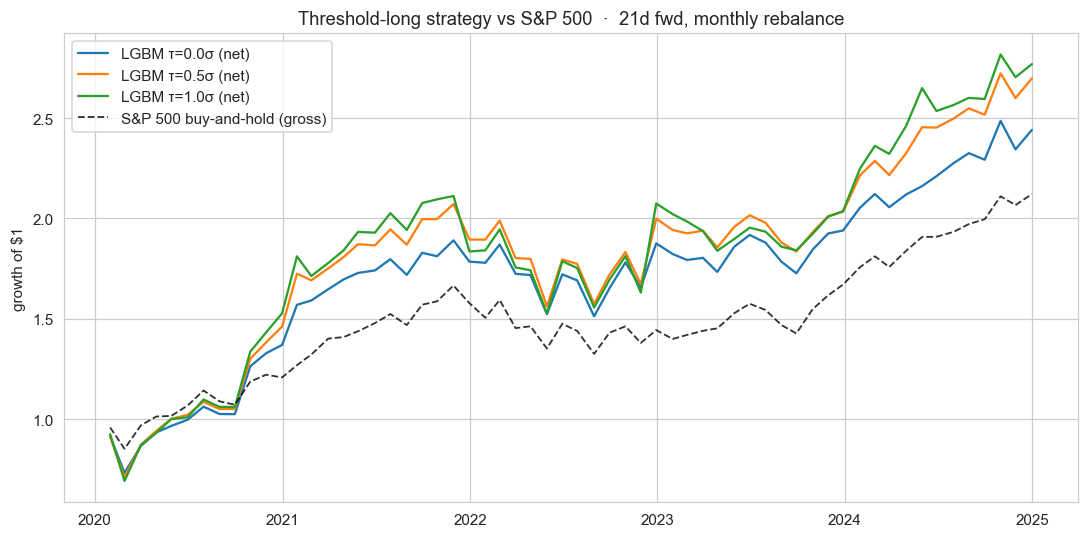

In [5]:
macro = pd.read_parquet(MACRO)
spx_ret = macro["sp500_close"].pct_change().dropna()

# Build a monthly SPX return aligned to our rebalance dates (buy-and-hold,
# not rebalanced) — sample 21d forward returns on each rebalance date.
spx = macro["sp500_close"]
spx_fwd = (spx.shift(-21) / spx - 1)
spx_monthly = spx_fwd.reindex(rebal_dates.values)

fig, ax = plt.subplots(figsize=(10, 5))
for t, df in results.items():
    eq = (1 + df["ret_net"]).cumprod()
    ax.plot(eq.index, eq.values, label=f"LGBM τ={t:.1f}σ (net)")
eq_spx = (1 + spx_monthly.fillna(0)).cumprod()
ax.plot(eq_spx.index, eq_spx.values, "k--", lw=1.2, alpha=0.8,
        label="S&P 500 buy-and-hold (gross)")
ax.set_title("Threshold-long strategy vs S&P 500  ·  21d fwd, monthly rebalance")
ax.set_ylabel("growth of $1")
ax.legend()
plt.tight_layout();

## 4. All models at τ=0

In [6]:
all_models = {}
for c in pred_cols:
    name = c.removeprefix("pred_")
    df = backtest_threshold(c, tau_sigmas=0.0)
    all_models[name] = summarise(df)

comparison = pd.DataFrame(all_models).T
comparison.round(3)

,periods,mean_n,CAGR,Sharpe,MaxDD,mean_TO
linear_ridge,60.0,205.0,0.213,0.895,-0.224,0.277
linear_lasso,60.0,203.0,0.222,0.920,-0.225,0.261
lgbm_regressor,60.0,218.0,0.195,0.851,-0.200,0.314
xgb_regressor,60.0,223.0,0.207,0.893,-0.201,0.332
hist_mean,60.0,216.0,0.222,1.053,-0.220,0.029


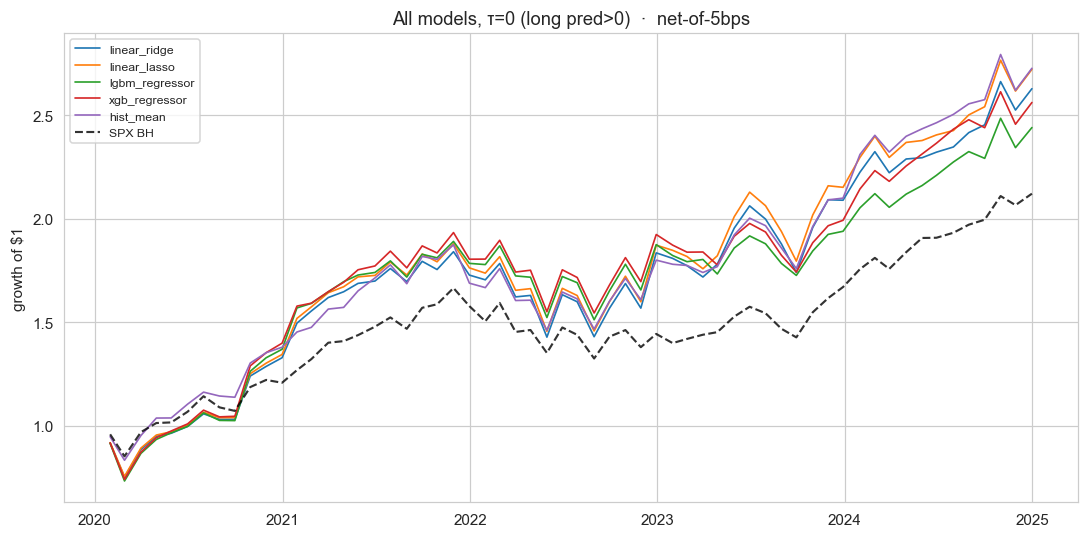

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
for c in pred_cols:
    name = c.removeprefix("pred_")
    df = backtest_threshold(c, tau_sigmas=0.0)
    eq = (1 + df["ret_net"]).cumprod()
    ax.plot(eq.index, eq.values, label=name, lw=1.1)
eq_spx = (1 + spx_monthly.fillna(0)).cumprod()
ax.plot(eq_spx.index, eq_spx.values, "k--", lw=1.4, alpha=0.8, label="SPX BH")
ax.set_title("All models, τ=0 (long pred>0)  ·  net-of-5bps")
ax.set_ylabel("growth of $1")
ax.legend(fontsize=8)
plt.tight_layout();

## Takeaways

At τ=0 the strategy is essentially long most of the universe most of the time, so the equity curves track the S&P 500 closely. Any outperformance is a small skill-over-market premium. Raising τ shrinks the basket without improving Sharpe — the magnitudes just don't rank as reliably as the signs do. A proper ranker (`ml-cross-sectional`) uses cross-sectional top-quintile selection instead of a threshold, which is a more robust construction on this kind of noisy target. Notebook 05 makes that comparison explicit.